# introduction

Name : Hernanda Rifaldi

Batch : HCK-037

Objective : Membuat sistem klasifikasi untuk mengidentifikasi jenis bag secara otomatis, sehingga data visual sebelumnya yang tidak terstruktur menjadi informasi yang terukur. informasi tersebut dapat dimanfaatkan sebagai monitoring komposisi sampah, evaluasi efisiensi proses pemilahan sampah. serta mendukung keputusan operasional berbasis data.

# Import Libraries

In [ ]:
# Import libraries

import os
import cv2
import glob
import random
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import shutil


import tensorflow as tf
from tensorflow.keras.models import Model, Sequential
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras.layers import (
    Conv2D,
    MaxPooling2D,
    Flatten,
    Dense,
    Dropout,
    BatchNormalization,
    GlobalAveragePooling2D
)
from pathlib import Path
from PIL import Image
from tensorflow.keras.preprocessing import image
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.applications.mobilenet_v2 import preprocess_input as preprocess_input_mobilenet
from tensorflow.keras.models import Sequential

import seaborn as sns
import matplotlib.pyplot as plt


from sklearn.metrics import confusion_matrix, classification_report
import warnings
warnings.filterwarnings('ignore')

# Check TensorFlow version
print(tf.__version__)

2.18.0


# Data Loading

In [47]:
# import os
# import shutil
# import random

# source = "archive/Bag_Classes/Bag_Classes"
# dest = "dataset"

# split_ratio = (0.7, 0.2, 0.1)

# classes = os.listdir(source)

# for c in classes:
#     files = os.listdir(os.path.join(source,c))
#     random.shuffle(files)

#     n = len(files)
#     train_end = int(split_ratio[0]*n)
#     val_end = int((split_ratio[0]+split_ratio[1])*n)

#     splits = {
#         "train": files[:train_end],
#         "val": files[train_end:val_end],
#         "test": files[val_end:]
#     }

#     for split in splits:
#         folder = os.path.join(dest, split, c)
#         os.makedirs(folder, exist_ok=True)

#         for f in splits[split]:
#             src = os.path.join(source,c,f)
#             dst = os.path.join(folder,f)
#             shutil.copy(src,dst)

# EDA

## Class Distribution

In [48]:
from pathlib import Path
import pandas as pd

base_path = Path("dataset")

data = []

for split in ["train", "val", "test"]:
    split_path = base_path / split
    
    for class_dir in split_path.iterdir():
        if class_dir.is_dir():
            count = len(list(class_dir.glob("*")))
            data.append([split, class_dir.name, count])

df = pd.DataFrame(data, columns=["dataset", "class", "count"])
print(df)

  dataset               class  count
0   train  Garbage Bag Images   3500
1   train    Paper Bag Images   3500
2   train  Plastic Bag Images   3500
3     val  Garbage Bag Images   1000
4     val    Paper Bag Images   1000
5     val  Plastic Bag Images   1000
6    test  Garbage Bag Images    500
7    test    Paper Bag Images    500
8    test  Plastic Bag Images    500


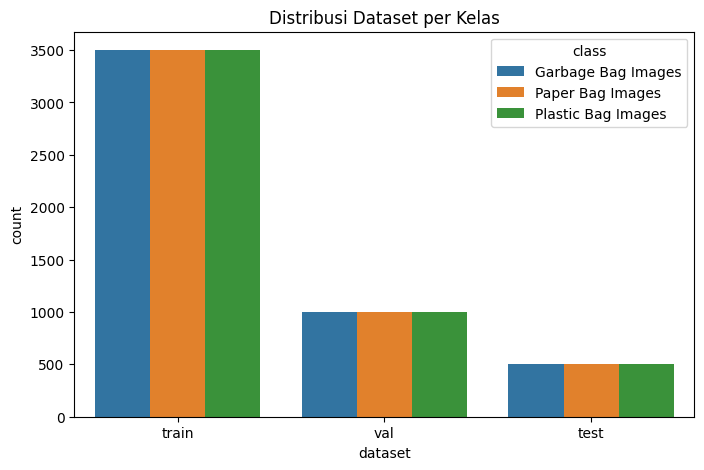

In [ ]:


plt.figure(figsize=(8, 5))
sns.barplot(data=df, x="dataset", y="count", hue="class")
plt.title("Distribusi Dataset per Kelas")
plt.show()

Distribusi dataset menunjukkan bahwa setiap kelas, yaitu Garbage Bag Images, Paper Bag Images, dan Plastic Bag Images, memiliki jumlah data yang seimbang pada masing-masing subset train, validation, dan test. Pada data train terdapat masing-masing 3500 gambar per kelas, pada validation 1000 gambar per kelas, dan pada test 500 gambar per kelas. Kondisi ini menunjukkan bahwa dataset bersifat balanced sehingga tidak terdapat dominasi kelas tertentu. Dengan distribusi yang seimbang ini, model yang dilatih memiliki peluang lebih baik untuk belajar secara adil terhadap setiap kelas dan mengurangi risiko bias dalam proses klasifikasi.

## Image per class

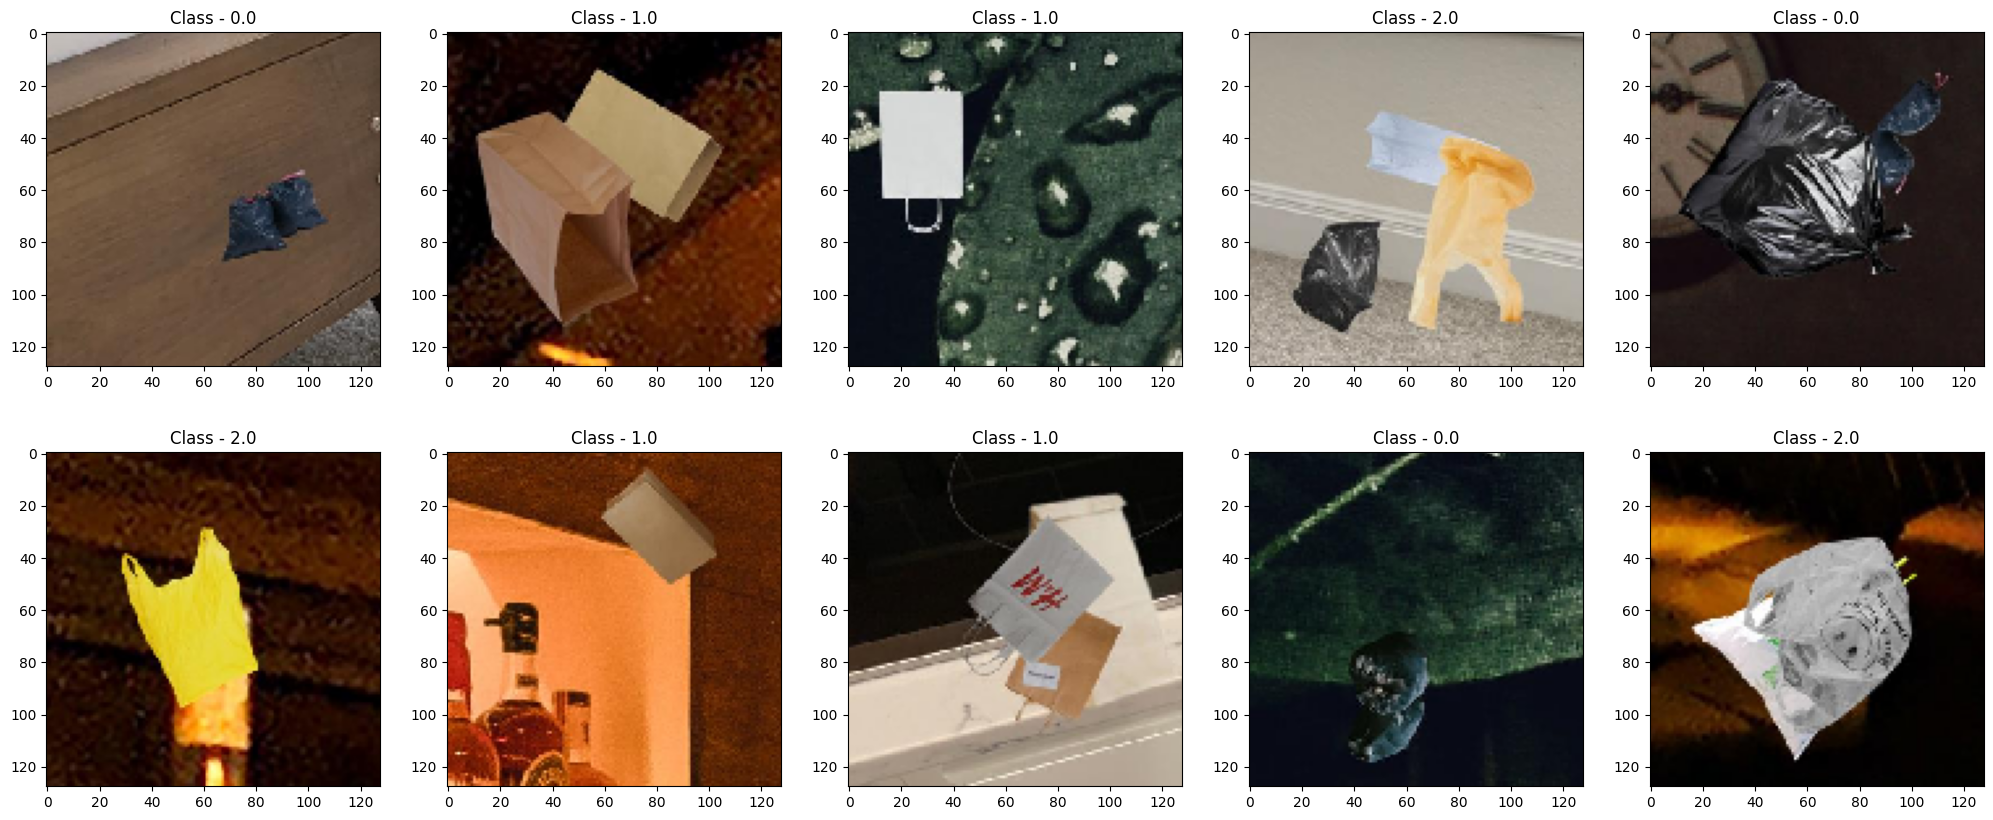

In [50]:
# Show images of train-set

fig, ax = plt.subplots(nrows=2, ncols=5, figsize=(25,10))
n = 0

for i in range(2):
  for j in range(5):
    img = (train_set[0][0][n] * 255).astype('uint8')
    ax[i][j].imshow(img)
    ax[i][j].set_title('Class - ' + str(train_set[0][1][n]))
    n += 1

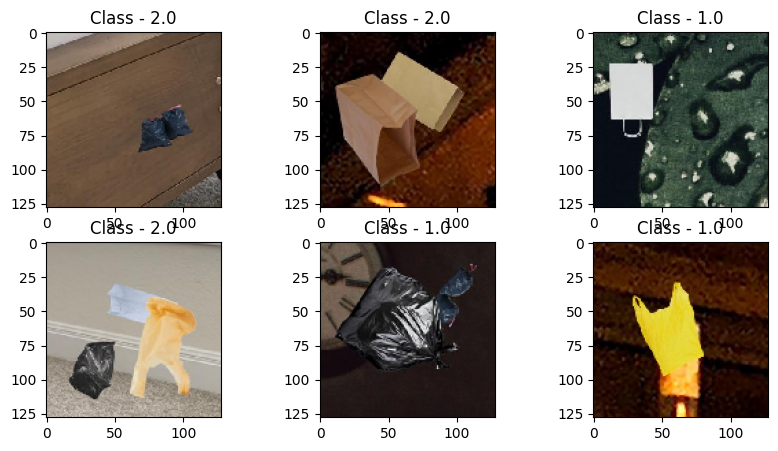

In [51]:
# Show images of val-set

fig, ax = plt.subplots(nrows=2, ncols=3, figsize=(10,5))
n = 0

for i in range(2):
  for j in range(3):
    img = (train_set[0][0][n] * 255).astype('uint8')
    ax[i][j].imshow(img)
    ax[i][j].set_title('Class - ' + str(val_set[0][1][n]))
    n += 1

In [52]:
train_set.class_indices

{'Garbage Bag Images': 0, 'Paper Bag Images': 1, 'Plastic Bag Images': 2}

Visualisasi image per class menunjukkan contoh beberapa gambar dari masing-masing kelas dalam dataset, yaitu Class 0, Class 1, dan Class 2. Setiap gambar diberi label sesuai dengan kelasnya, sehingga memudahkan dalam melihat perbedaan karakteristik visual antar kelas. Terlihat bahwa setiap kelas memiliki ciri khas objek yang berbeda, seperti bentuk, warna, dan tekstur kantong yang digunakan. Variasi latar belakang, pencahayaan, dan sudut pengambilan gambar juga cukup beragam, yang menunjukkan bahwa dataset memiliki kompleksitas yang baik. Hal ini penting karena membantu model dalam belajar mengenali objek secara lebih robust dan tidak hanya bergantung pada kondisi tertentu. Dengan adanya visualisasi ini, dapat dipastikan bahwa data yang digunakan sudah representatif dan sesuai untuk proses pelatihan model klasifikasi.

# Feature Engineering

In [61]:
# Define hyperparameters

img_height= 128
img_width= 128
batch_size= 64

ukuran ini dipilih karena ukuran pixel cukup kecil sehingga training akan lebih cepat. penggunaan memori yang ringan. dirasa masih cukup untuk mempertahankan fitur penting gambar.

In [62]:
datagen = ImageDataGenerator(rescale=1./255)
train_set = datagen.flow_from_directory(
    "dataset/train",
    target_size=(img_height,img_width),
    batch_size=batch_size,
    class_mode="sparse"
)

val_set = datagen.flow_from_directory(
    "dataset/val",
    target_size=(img_height,img_width),
    batch_size=batch_size,
    class_mode="sparse"
)

test_set = datagen.flow_from_directory(
    "dataset/test",
    target_size=(img_height,img_width),
    batch_size=batch_size,
    class_mode="sparse",
    shuffle=False
)

Found 10500 images belonging to 3 classes.
Found 3000 images belonging to 3 classes.
Found 1500 images belonging to 3 classes.


Kode tersebut digunakan untuk memuat dataset gambar dari folder train, val, dan test menggunakan ImageDataGenerator. Seluruh gambar dinormalisasi dengan rescale=1./255 dan diubah ukurannya sesuai input model. Data latih digunakan untuk proses pembelajaran, data validasi untuk memantau performa model selama training, dan data uji untuk evaluasi akhir. Hasil output menunjukkan bahwa dataset terdiri dari 10.500 gambar training, 3.000 gambar validation, dan 1.500 gambar testing yang terbagi ke dalam 3 kelas.

# ANN Training

## Model Definition

In [63]:
# Clear session
seed = 20
tf.keras.backend.clear_session()
np.random.seed(seed)
tf.random.set_seed(seed)

Model training pertama disini tidak menggunakan image Augmentation. hal ini didasari karena melihat semua dataset gambar seperti gambar yang telah teraugmentasi, maka dari itu ANN training pertama tidak menggunakannya. bisa dilihat pada EDA image per class

In [ ]:
# Create Sequential API model

model = Sequential([

Conv2D(32,(3,3),activation='relu',input_shape=(img_height,img_width,3)),
BatchNormalization(),
MaxPooling2D(2,2),

Conv2D(64,(3,3),activation='relu'),
BatchNormalization(),
MaxPooling2D(2,2),

Conv2D(128,(3,3),activation='relu'),
BatchNormalization(),
MaxPooling2D(2,2),

GlobalAveragePooling2D(),

Dropout(0.5),

Dense(128,activation='relu'),
Dense(3,activation='softmax')

])

# Compile
model.compile(loss='sparse_categorical_crossentropy',
              optimizer='adam',
              metrics=['accuracy'])
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 126, 126, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 126, 126, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 63, 63, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 61, 61, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 61, 61, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 30, 30, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 28, 28, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 28, 28, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 14, 14, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 128)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │        16,512 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 3)              │           387 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 111,043 (433.76 KB)

 Trainable params: 110,595 (432.01 KB)

 Non-trainable params: 448 (1.75 KB)

Kode tersebut digunakan untuk membangun model Convolutional Neural Network (CNN) dengan arsitektur Sequential API dari TensorFlow/Keras untuk tugas klasifikasi gambar.Model Sequential digunakan karena arsitektur jaringan yang dibangun bersifat sederhana dan tersusun secara berurutan dari layer pertama hingga layer terakhir. Setiap layer pada model menerima input dari layer sebelumnya dan meneruskan output ke layer berikutnya tanpa adanya percabangan atau struktur yang kompleks. Model terdiri dari tiga lapisan Conv2D yang berfungsi mengekstraksi fitur, dan setiap lapisan diikuti oleh BatchNormalization untuk menstabilkan proses pelatihan serta MaxPooling2D untuk mengurangi dimensi fitur. Setelah proses ekstraksi fitur, digunakan GlobalAveragePooling2D untuk merangkum informasi penting dari feature map, kemudian Dropout sebesar 0.5 diterapkan untuk mengurangi risiko overfitting. Pada bagian akhir, terdapat lapisan Dense dengan 128 neuron dan aktivasi ReLU sebagai fully connected layer, serta lapisan output dengan 3 neuron dan aktivasi softmax untuk menghasilkan prediksi ke dalam 3 kelas. Model kemudian dikompilasi menggunakan fungsi loss sparse_categorical_crossentropy, optimizer Adam, dan metrik accuracy untuk mengukur performa model.

## Model Training

In [65]:
# Train the model

history = model.fit(train_set, epochs=21, validation_data=val_set, batch_size=batch_size)

Epoch 1/21
165/165 ━━━━━━━━━━━━━━━━━━━━ 159s 946ms/step - accuracy: 0.6272 - loss: 0.8210 - val_accuracy: 0.5223 - val_loss: 0.9876
Epoch 2/21
165/165 ━━━━━━━━━━━━━━━━━━━━ 143s 866ms/step - accuracy: 0.8317 - loss: 0.4191 - val_accuracy: 0.5243 - val_loss: 1.0900
Epoch 3/21
165/165 ━━━━━━━━━━━━━━━━━━━━ 140s 847ms/step - accuracy: 0.8925 - loss: 0.2875 - val_accuracy: 0.5620 - val_loss: 1.2016
Epoch 4/21
165/165 ━━━━━━━━━━━━━━━━━━━━ 145s 879ms/step - accuracy: 0.9187 - loss: 0.2153 - val_accuracy: 0.7293 - val_loss: 0.6898
Epoch 5/21
165/165 ━━━━━━━━━━━━━━━━━━━━ 143s 863ms/step - accuracy: 0.9319 - loss: 0.1915 - val_accuracy: 0.6477 - val_loss: 1.5844
Epoch 6/21
165/165 ━━━━━━━━━━━━━━━━━━━━ 142s 861ms/step - accuracy: 0.9284 - loss: 0.1941 - val_accuracy: 0.8217 - val_loss: 0.4712
Epoch 7/21
165/165 ━━━━━━━━━━━━━━━━━━━━ 142s 858ms/step - accuracy: 0.9471 - loss: 0.1448 - val_accuracy: 0.9037 - val_loss: 0.2354
Epoch 8/21
165/165 ━━━━━━━━━━━━━━━━━━━━ 142s 860ms/step - accuracy: 0.9557 -

## Model Evaluation

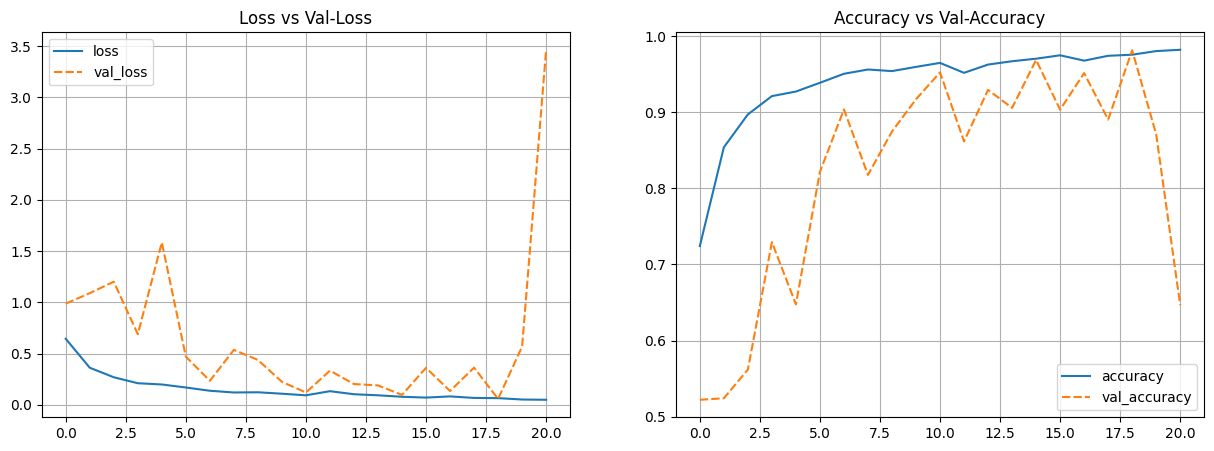

In [66]:
# Plot training results

history_df = pd.DataFrame(history.history)

plt.figure(figsize=(15, 5))
plt.subplot(1, 2, 1)
sns.lineplot(data=history_df[['loss', 'val_loss']])
plt.grid()
plt.title('Loss vs Val-Loss')

plt.subplot(1, 2, 2)
sns.lineplot(data=history_df[['accuracy', 'val_accuracy']])
plt.grid()
plt.title('Accuracy vs Val-Accuracy')
plt.show()

In [67]:
# Check the performance of test-set

## Get the probability
y_pred_prob = model.predict(test_set)

## Get class with maximum probability
y_pred_class = np.argmax(y_pred_prob, axis=-1)

## Display Classification Report
print(classification_report(test_set.classes, y_pred_class, target_names=np.array(list(train_set.class_indices.keys()))))

24/24 ━━━━━━━━━━━━━━━━━━━━ 6s 231ms/step
                    precision    recall  f1-score   support

Garbage Bag Images       1.00      0.38      0.55       500
  Paper Bag Images       0.97      0.57      0.72       500
Plastic Bag Images       0.49      0.99      0.66       500

          accuracy                           0.65      1500
         macro avg       0.82      0.65      0.64      1500
      weighted avg       0.82      0.65      0.64      1500



Berdasarkan classification report, model memperoleh akurasi sebesar 65% pada data uji, yang menunjukkan bahwa performa model masih belum optimal dalam membedakan ketiga kelas. Kelas Garbage Bag Images memiliki precision 1.00 namun recall 0.38, yang berarti ketika model memprediksi kelas ini hasilnya sangat tepat, tetapi masih banyak data Garbage Bag yang gagal terdeteksi. Pada kelas Paper Bag Images, model menunjukkan performa yang cukup lebih baik dengan precision 0.97, recall 0.57, dan f1-score 0.72, meskipun masih terdapat cukup banyak data yang belum berhasil dikenali dengan baik. Sementara itu, kelas Plastic Bag Images memiliki recall sangat tinggi sebesar 0.99, tetapi precision hanya 0.49, yang menandakan bahwa model cenderung terlalu sering memprediksi gambar sebagai Plastic Bag sehingga banyak prediksi pada kelas ini tidak tepat. Secara keseluruhan, nilai macro average f1-score sebesar 0.64 menunjukkan bahwa model masih belum seimbang dalam melakukan klasifikasi pada seluruh kelas.

# ANN Improvement

## Model with Augmented

Penambahan model dengan image Augmentation

## Model Definition

In [69]:
train_datagen = tf.keras.preprocessing.image.ImageDataGenerator(
    rescale=1./255,
    validation_split=0.2,
    
    rotation_range=20,
    width_shift_range=0.1,
    height_shift_range=0.1,
    zoom_range=0.2,
    shear_range=0.1,
    horizontal_flip=True,
    fill_mode="nearest"
)

ImageDataGenerator digunakan untuk melakukan preprocessing dan augmentasi data agar model dapat belajar dari variasi gambar yang lebih beragam. Parameter rescale digunakan untuk menormalisasi nilai piksel, sedangkan validation_split membagi data menjadi data training dan validation. Teknik augmentasi seperti rotation, shift, zoom, shear, dan horizontal flip bertujuan untuk meningkatkan variasi data sehingga model menjadi lebih robust dan mampu melakukan generalisasi dengan lebih baik terhadap data baru.

In [70]:
train_set_aug = train_datagen.flow_from_directory(
    "dataset/train",
    target_size=(img_height, img_width),
    class_mode='sparse',
    batch_size=batch_size,
    shuffle=True
)

val_set_aug = train_datagen.flow_from_directory(
    "dataset/val",
    target_size=(img_height, img_width),
    class_mode='sparse',
    batch_size=batch_size,
    shuffle=True
)

test_set_aug = train_datagen.flow_from_directory(
    "dataset/test",
    target_size=(img_height, img_width),
    class_mode='sparse',
    batch_size=batch_size,
    shuffle=False
)

Found 10500 images belonging to 3 classes.
Found 3000 images belonging to 3 classes.
Found 1500 images belonging to 3 classes.


In [79]:
# Clear session

seed = 20
tf.keras.backend.clear_session()
np.random.seed(seed)
tf.random.set_seed(seed)

In [ ]:
# Create Sequential API model

model_aug = Sequential([

Conv2D(32,(3,3),activation='relu',input_shape=(img_height,img_width,3)),
BatchNormalization(),
MaxPooling2D(2,2),

Conv2D(64,(3,3),activation='relu'),
BatchNormalization(),
MaxPooling2D(2,2),

Conv2D(128,(3,3),activation='relu'),
BatchNormalization(),
MaxPooling2D(2,2),

GlobalAveragePooling2D(),

Dropout(0.5),

Dense(128,activation='relu'),
Dense(3,activation='softmax')

])

# Compile
model_aug.compile(loss='sparse_categorical_crossentropy',
              optimizer='adam',
              metrics=['accuracy'])
model_aug.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_3 (Conv2D)               │ (None, 126, 126, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 126, 126, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 63, 63, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 61, 61, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_4           │ (None, 61, 61, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (None, 30, 30, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 28, 28, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_5           │ (None, 28, 28, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_5 (MaxPooling2D)  │ (None, 14, 14, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_1      │ (None, 128)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 128)            │        16,512 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 3)              │           387 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 111,043 (433.76 KB)

 Trainable params: 110,595 (432.01 KB)

 Non-trainable params: 448 (1.75 KB)

untuk layernya sama seperti model ANN pertama, dikarenakan ingin membandingkan hasil dari improvement model ini.

## Model Training

In [82]:
# Train the model

history_aug = model_aug.fit(train_set_aug, epochs=21, validation_data=val_set_aug, batch_size=batch_size)

Epoch 1/21
165/165 ━━━━━━━━━━━━━━━━━━━━ 230s 1s/step - accuracy: 0.6275 - loss: 0.8292 - val_accuracy: 0.3343 - val_loss: 1.3687
Epoch 2/21
165/165 ━━━━━━━━━━━━━━━━━━━━ 262s 2s/step - accuracy: 0.8472 - loss: 0.3904 - val_accuracy: 0.3770 - val_loss: 1.7541
Epoch 3/21
165/165 ━━━━━━━━━━━━━━━━━━━━ 254s 2s/step - accuracy: 0.8892 - loss: 0.3065 - val_accuracy: 0.4517 - val_loss: 1.7554
Epoch 4/21
165/165 ━━━━━━━━━━━━━━━━━━━━ 265s 2s/step - accuracy: 0.9026 - loss: 0.2536 - val_accuracy: 0.6640 - val_loss: 0.8724
Epoch 5/21
165/165 ━━━━━━━━━━━━━━━━━━━━ 257s 2s/step - accuracy: 0.9158 - loss: 0.2289 - val_accuracy: 0.8667 - val_loss: 0.3002
Epoch 6/21
165/165 ━━━━━━━━━━━━━━━━━━━━ 230s 1s/step - accuracy: 0.9256 - loss: 0.1976 - val_accuracy: 0.6583 - val_loss: 1.1187
Epoch 7/21
165/165 ━━━━━━━━━━━━━━━━━━━━ 237s 1s/step - accuracy: 0.8825 - loss: 0.3124 - val_accuracy: 0.8987 - val_loss: 0.2894
Epoch 8/21
165/165 ━━━━━━━━━━━━━━━━━━━━ 236s 1s/step - accuracy: 0.9328 - loss: 0.1893 - val_accu

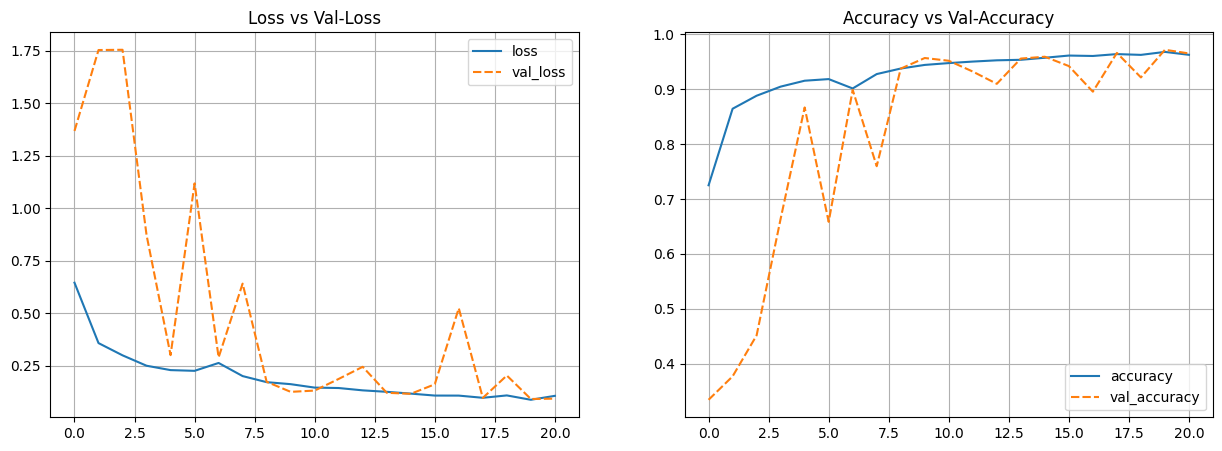

In [83]:
history_aug_df = pd.DataFrame(history_aug.history)

plt.figure(figsize=(15, 5))
plt.subplot(1, 2, 1)
sns.lineplot(data=history_aug_df[['loss', 'val_loss']])
plt.grid()
plt.title('Loss vs Val-Loss')

plt.subplot(1, 2, 2)
sns.lineplot(data=history_aug_df[['accuracy', 'val_accuracy']])
plt.grid()
plt.title('Accuracy vs Val-Accuracy')
plt.show()

Pada grafik accuracy, terlihat bahwa akurasi training meningkat secara signifikan hingga mencapai nilai yang tinggi dan stabil. Akurasi validation juga menunjukkan peningkatan meskipun sempat mengalami fluktuasi pada beberapa epoch, namun secara keseluruhan mengikuti tren peningkatan akurasi training. Perbedaan antara accuracy training dan validation tidak terlalu besar, sehingga dapat disimpulkan bahwa model tidak mengalami overfitting yang signifikan dan memiliki performa yang cukup baik dalam mengklasifikasikan data baru.

In [84]:
# Check the performance of test-set

## Get the probability
y_pred_prob_aug = model_aug.predict(test_set)

## Get class with maximum probability
y_pred_class_aug = np.argmax(y_pred_prob_aug, axis=-1)

## Display Classification Report
print(classification_report(test_set_aug.classes, y_pred_class_aug, target_names=np.array(list(train_set_aug.class_indices.keys()))))

24/24 ━━━━━━━━━━━━━━━━━━━━ 6s 230ms/step
                    precision    recall  f1-score   support

Garbage Bag Images       0.94      1.00      0.97       500
  Paper Bag Images       0.97      0.97      0.97       500
Plastic Bag Images       0.97      0.92      0.95       500

          accuracy                           0.96      1500
         macro avg       0.96      0.96      0.96      1500
      weighted avg       0.96      0.96      0.96      1500



Hasil classification report menunjukkan bahwa model memiliki performa yang baik pada data augmented. Nilai precision, recall, dan f1-score untuk semua kelas berada pada kisaran tinggi (±0.94–0.97). Accuracy sebesar 0.96 menandakan model mampu mengklasifikasikan data dengan sangat baik. Performa antar kelas juga seimbang, sehingga model tidak bias dan memiliki kemampuan generalisasi yang baik.

## Model With Transfer Learning

### Preprocessing

In [ ]:
# Clear session

seed = 20
tf.keras.backend.clear_session()
np.random.seed(seed)
tf.random.set_seed(seed)

In [ ]:


pretrained_model_mobilenet = MobileNetV2(
    weights='imagenet',
    include_top=False,
    input_shape=(img_height, img_width, 3)
)

pretrained_model_mobilenet.trainable = False

In [ ]:
train_datagen_tl = tf.keras.preprocessing.image.ImageDataGenerator(
    preprocessing_function=preprocess_input_mobilenet,
    validation_split=0.2,
    
    rotation_range=20,
    width_shift_range=0.1,
    height_shift_range=0.1,
    zoom_range=0.2,
    shear_range=0.1,
    horizontal_flip=True,
    fill_mode="nearest"
)

In [ ]:
train_set_aug_tl = train_datagen_tl.flow_from_directory(
    "dataset/train",
    target_size=(img_height, img_width),
    class_mode='sparse',
    batch_size=batch_size,
    shuffle=True
)

val_set_aug_tl = train_datagen_tl.flow_from_directory(
    "dataset/val",
    target_size=(img_height, img_width),
    class_mode='sparse',
    batch_size=batch_size,
    shuffle=True
)

test_set_aug_tl = train_datagen_tl.flow_from_directory(
    "dataset/test",
    target_size=(img_height, img_width),
    class_mode='sparse',
    batch_size=batch_size,
    shuffle=False
)

Found 10500 images belonging to 3 classes.
Found 3000 images belonging to 3 classes.
Found 1500 images belonging to 3 classes.


In [ ]:
model_aug_tl = ([
    pretrained_model_mobilenet,
    GlobalAveragePooling2D(),
    Dropout(0.3),
    Dense(128, activation='relu'),
    Dense(3, activation='softmax')
])

model_aug_tl.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

Arsitektur ini digunakan karena transfer learning dengan MobileNet mampu menghasilkan ekstraksi fitur yang lebih baik dibanding CNN biasa, terutama pada dataset yang terbatas. Penambahan GlobalAveragePooling2D, Dropout, dan Dense layer membantu model menjadi lebih efisien, lebih stabil, dan mampu melakukan klasifikasi 3 kelas dengan akurasi yang tinggi.`

### Model Training

In [ ]:
history_aug_tl = model_aug_tl.fit(
    train_set_aug_tl,
    validation_data=val_set_aug_tl,
    epochs=20
)

Epoch 1/20
165/165 ━━━━━━━━━━━━━━━━━━━━ 146s 843ms/step - accuracy: 0.8224 - loss: 0.4642 - val_accuracy: 0.9400 - val_loss: 0.1566
Epoch 2/20
165/165 ━━━━━━━━━━━━━━━━━━━━ 140s 849ms/step - accuracy: 0.9372 - loss: 0.1639 - val_accuracy: 0.9423 - val_loss: 0.1634
Epoch 3/20
165/165 ━━━━━━━━━━━━━━━━━━━━ 155s 936ms/step - accuracy: 0.9382 - loss: 0.1527 - val_accuracy: 0.9533 - val_loss: 0.1353
Epoch 4/20
165/165 ━━━━━━━━━━━━━━━━━━━━ 133s 807ms/step - accuracy: 0.9453 - loss: 0.1413 - val_accuracy: 0.9570 - val_loss: 0.1176
Epoch 5/20
165/165 ━━━━━━━━━━━━━━━━━━━━ 141s 855ms/step - accuracy: 0.9540 - loss: 0.1157 - val_accuracy: 0.9637 - val_loss: 0.1026
Epoch 6/20
165/165 ━━━━━━━━━━━━━━━━━━━━ 131s 796ms/step - accuracy: 0.9541 - loss: 0.1154 - val_accuracy: 0.9643 - val_loss: 0.0961
Epoch 7/20
165/165 ━━━━━━━━━━━━━━━━━━━━ 161s 975ms/step - accuracy: 0.9574 - loss: 0.1091 - val_accuracy: 0.9557 - val_loss: 0.1233
Epoch 8/20
165/165 ━━━━━━━━━━━━━━━━━━━━ 2207s 13s/step - accuracy: 0.9586 - 

## Model Evaluation

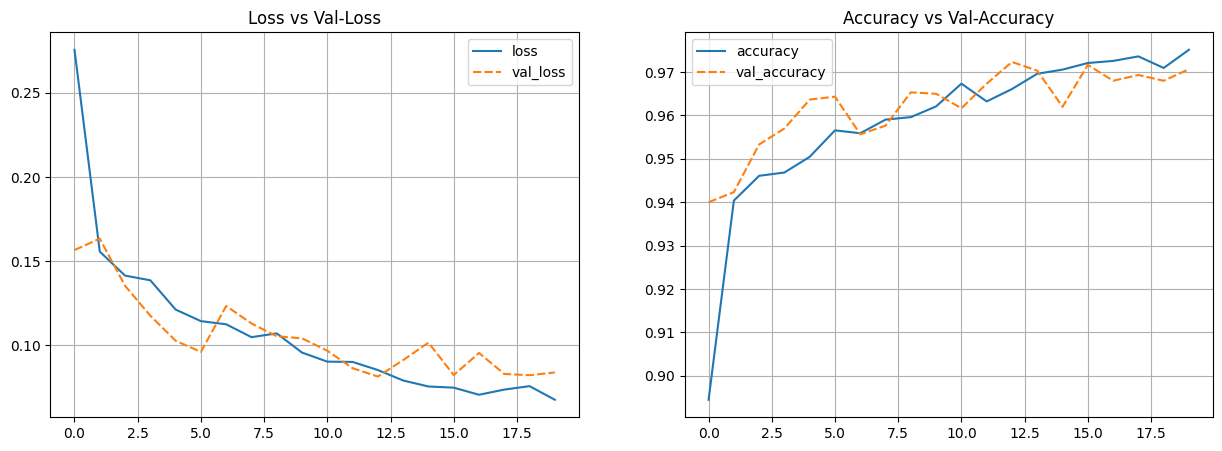

In [ ]:
history_aug_tl_df = pd.DataFrame(history_aug_tl.history)

plt.figure(figsize=(15, 5))
plt.subplot(1, 2, 1)
sns.lineplot(data=history_aug_tl_df[['loss', 'val_loss']])
plt.grid()
plt.title('Loss vs Val-Loss')

plt.subplot(1, 2, 2)
sns.lineplot(data=history_aug_tl_df[['accuracy', 'val_accuracy']])
plt.grid()
plt.title('Accuracy vs Val-Accuracy')
plt.show()

Pada grafik accuracy, terlihat bahwa akurasi training meningkat secara konsisten hingga mencapai nilai tinggi, dan akurasi validation juga mengikuti pola yang serupa dengan fluktuasi kecil namun tetap berada pada nilai yang tinggi. Kedua kurva berada pada rentang yang hampir sama, yang menunjukkan bahwa model memiliki kemampuan generalisasi yang baik terhadap data yang belum pernah dilihat sebelumnya.

Berdasarkan pola tersebut, model dapat dikategorikan sebagai good fit, karena tidak menunjukkan tanda underfitting (akurasi rendah dan loss tinggi) maupun overfitting (gap besar antara training dan validation). Model sudah mampu menangkap pola data dengan baik dan memberikan performa yang stabil pada data training maupun validation.
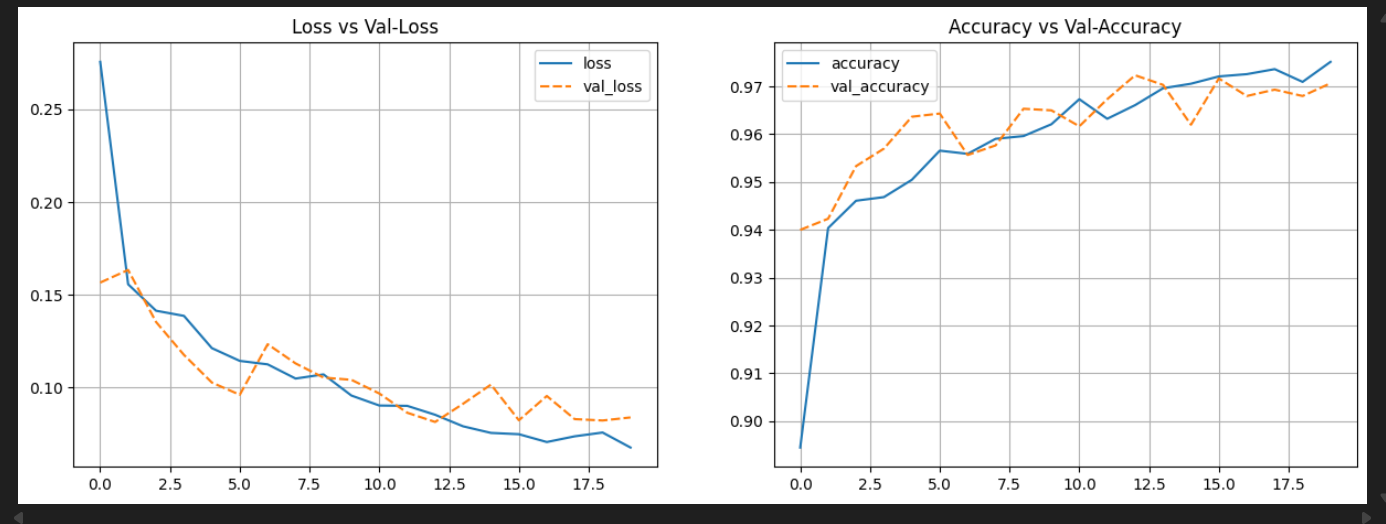

In [ ]:
# Check the performance of test-set

## Get the probability
y_pred_prob_aug_tl = model_aug_tl.predict(test_set_aug_tl)

## Get class with maximum probability
y_pred_class_aug_tl = np.argmax(y_pred_prob_aug_tl, axis=-1)

## Display Classification Report
print(classification_report(test_set_aug_tl.classes, y_pred_class_aug_tl, target_names=np.array(list(train_set_aug_tl.class_indices.keys()))))

24/24 ━━━━━━━━━━━━━━━━━━━━ 16s 610ms/step
                    precision    recall  f1-score   support

Garbage Bag Images       0.97      0.98      0.98       500
  Paper Bag Images       0.95      0.98      0.97       500
Plastic Bag Images       0.98      0.93      0.96       500

          accuracy                           0.97      1500
         macro avg       0.97      0.97      0.97      1500
      weighted avg       0.97      0.97      0.97      1500



Berdasarkan classification report, kombinasi data augmentation dan transfer learning menghasilkan performa model terbaik dengan akurasi sebesar 97% pada data uji. Kelas Garbage Bag Images memperoleh precision 0.97, recall 0.98, dan f1-score 0.98, yang menunjukkan bahwa model sangat baik dalam mengenali kelas ini. Pada kelas Paper Bag Images, model juga menunjukkan performa yang sangat tinggi dengan precision 0.95, recall 0.98, dan f1-score 0.97, sehingga sebagian besar data pada kelas ini berhasil diklasifikasikan dengan benar. Sementara itu, kelas Plastic Bag Images memiliki precision 0.98, recall 0.93, dan f1-score 0.96, yang menandakan bahwa model sangat akurat saat memprediksi kelas tersebut meskipun masih terdapat sedikit data yang belum terdeteksi secara sempurna. Secara keseluruhan, nilai macro average dan weighted average yang sama-sama mencapai 0.97 menunjukkan bahwa model memiliki performa yang sangat baik, stabil, dan seimbang pada seluruh kelas. walau accuracy data hampir sama dengan yang augmentation, akan tetapi modeling memberikan waktu tercepat terlihat pada epoch pertama accuracy sudah menyampai 0.8 sedangkan modeling dengan data augmentation hanya 0.6.

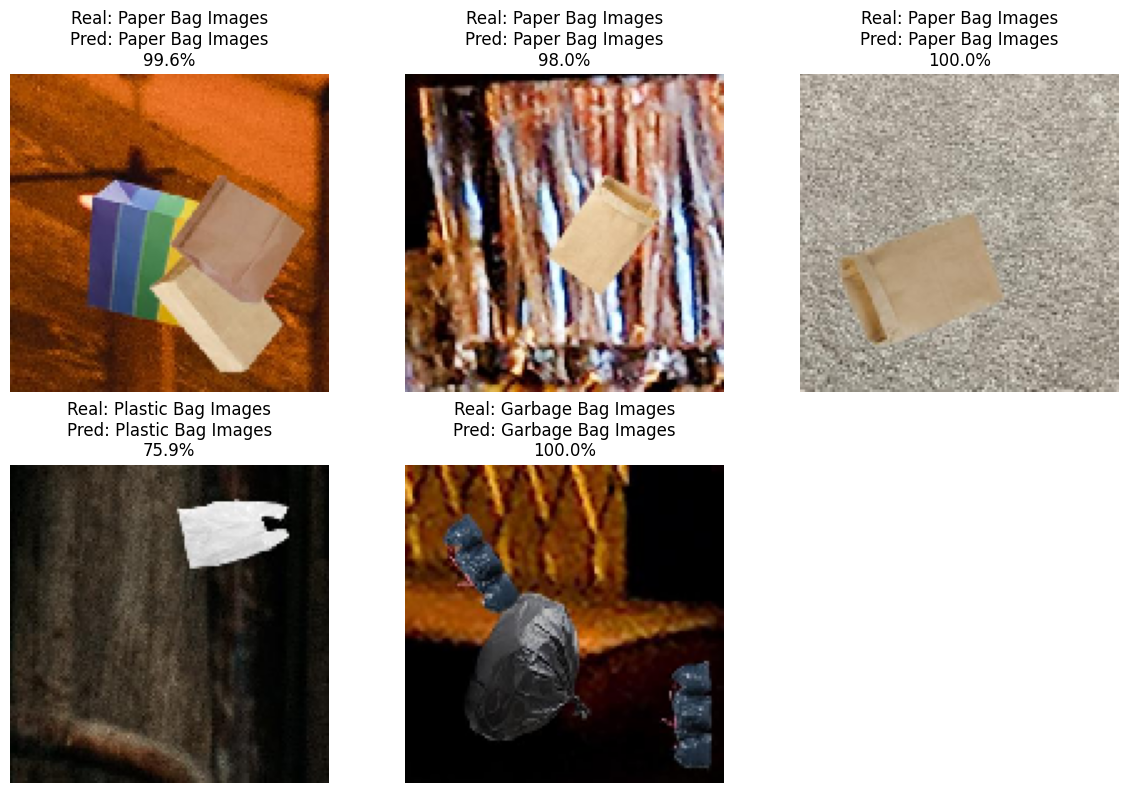

In [ ]:
class_names = list(test_set_aug_tl.class_indices.keys())

# ambil 5 index random dari test set
random_idx = random.sample(range(len(test_set_aug_tl.filepaths)), 5)

plt.figure(figsize=(12, 8))

for n, i in enumerate(random_idx):
    img_path = test_set_aug_tl.filepaths[i]
    true_label = class_names[test_set_aug_tl.classes[i]]

    img = image.load_img(img_path, target_size=(img_height, img_width))
    img_array = image.img_to_array(img) / 255.0
    img_array = np.expand_dims(img_array, axis=0)

    pred = model_aug_tl.predict(img_array, verbose=0)
    pred_index = np.argmax(pred)
    pred_label = class_names[pred_index]
    confidence = np.max(pred) * 100

    plt.subplot(2, 3, n + 1)
    plt.imshow(img)
    plt.title(f"Real: {true_label}\nPred: {pred_label}\n{confidence:.1f}%")
    plt.axis("off")

plt.tight_layout()
plt.show()

Visualisasi ini menunjukkan contoh hasil prediksi model pada beberapa gambar uji. Pada setiap gambar ditampilkan tiga informasi utama, yaitu label asli (Real), label hasil prediksi model (Pred), dan tingkat keyakinan model dalam bentuk persentase. Dari gambar tersebut terlihat bahwa model berhasil mengklasifikasikan beberapa sampel dengan benar, karena label prediksi sama dengan label aslinya.

Pada baris atas, ketiga sampel yang ditampilkan termasuk ke dalam kelas Paper Bag Images dan semuanya berhasil diprediksi dengan benar oleh model. Tingkat keyakinan model juga sangat tinggi, yaitu sekitar 98.0% hingga 100.0%, yang menunjukkan bahwa model sangat yakin terhadap hasil klasifikasinya pada gambar-gambar tersebut. Hal ini menandakan bahwa model mampu mengenali ciri visual paper bag dengan sangat baik.

Pada bagian bawah, terlihat pula contoh untuk kelas Plastic Bag Images dan Garbage Bag Images. Gambar Plastic Bag Images berhasil diprediksi dengan benar dengan confidence 75.9%, yang berarti model masih cukup yakin, meskipun tidak setinggi contoh pada kelas paper bag. Sementara itu, gambar Garbage Bag Images diprediksi benar dengan confidence 100.0%, yang menunjukkan bahwa model sangat yakin terhadap hasil tersebut.

Secara keseluruhan, visualisasi ini menunjukkan bahwa model sudah mampu mengenali objek pada beberapa sampel uji dengan baik, terutama pada kelas yang memiliki ciri visual yang cukup jelas. Perbedaan nilai confidence antar gambar juga menunjukkan bahwa tingkat keyakinan model dapat bervariasi tergantung pada kejelasan bentuk objek, kualitas gambar, latar belakang, dan kemiripan antar kelas.

## Saran Improvement Model
Meskipun model yang dibangun sudah menunjukkan performa yang sangat baik, masih terdapat beberapa hal yang dapat dilakukan untuk pengembangan lebih lanjut. Salah satunya adalah menambah variasi dan jumlah data latih agar model dapat mempeloleh representasi fitur yang lebih beragam serta lebih robust terhadap kondisi gambar yang berbeda. Selain itu, proses hyperparameter tuning seperti pengaturan learning rate, batch size, jumlah epoch, dan dropout dapat dioptimalkan untuk memperoleh performa yang lebih maksimal. Penggunaan arsitektur transfer learning lain, seperti EfficientNet atau ResNet, juga dapat dicoba sebagai pembanding untuk melihat kemungkinan peningkatan akurasi. Selanjutnya, evaluasi model pada data baru yang lebih bervariasi dan menyerupai kondisi nyata perlu dilakukan agar model tidak hanya baik pada dataset uji, tetapi juga mampu melakukan generalisasi dengan baik saat diimplementasikan pada aplikasi nyata.

# Model Saving

In [ ]:
model_aug_tl.save("model_inference.keras")

# Model Inference

In [ ]:
# Function to predict an image

def prediction(file, img_height=128, img_width=128):
  ## Load an image
  image_inf = tf.keras.utils.load_img(file, target_size=(img_height, img_width))

  ## Rescaling and reshaping image
  x = tf.keras.utils.img_to_array(image_inf)/255
  x = np.expand_dims(x, axis=0)
  image_infs = np.vstack([x])

  ## Predict
  y_pred_inf_proba_tl = model_aug_tl.predict(image_infs, batch_size=10)
  y_pred_inf_cls_tl = np.argmax(y_pred_inf_proba_tl)
  class_names = ['Garbage Bag Images', 'Paper Bag Images', 'Plastic Bag Images']
  y_pred_class_name_tl = class_names[np.argmax(y_pred_inf_proba_tl[0])]

  return image_inf, y_pred_class_name_tl

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 53ms/step
Prediction :  Plastic Bag Images


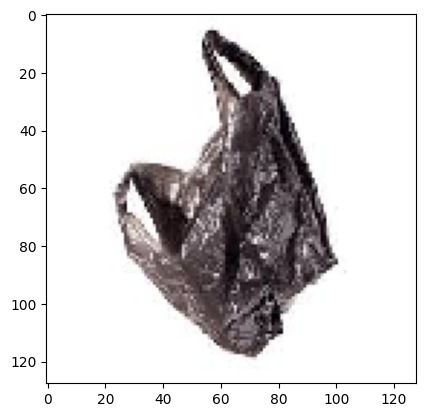

In [73]:
import urllib.request

url = "data:image/jpeg;base64,/9j/4AAQSkZJRgABAQAAAQABAAD/2wCEAAkGBxMTEhUUEhMWFRUVGCAZGRcWGBoXHxMaHBoaGB4XIRoYICghGhsoHB0XIjEhJSorLi8uHyAzODMtNygtLisBCgoKDg0OFRAPFS0dHR0tLS0tLS0tKysrLS0rLS0rKy0tLSstLS0vLSstKys3Ky0rLTctKy0rLSstLSstLS0tN//AABEIALcBEwMBIgACEQEDEQH/xAAcAAEAAgMBAQEAAAAAAAAAAAAABQYDBAcIAgH/xAA9EAABAwIDBgMFBwQBBAMAAAABAAIRAyEEEjEFBiJBUWETcYEHMkKRoRQjM1JicrGi0eHwwUOCwvFUg5L/xAAXAQEBAQEAAAAAAAAAAAAAAAAAAQID/8QAHREBAQEAAQUBAAAAAAAAAAAAAAERAhIhMVFxQf/aAAwDAQACEQMRAD8A7iiIgIiICIiAiIgIiICIiAiIgL5DhJEiRqOir++23BhqLWh+SriCaVJ1rVC0luthcAeZC850sfWo1RiaVWoKpcSahc5r3Hnmk3PUHmOiLJr1ci5Luz7YWFgbjG8QgZ6YMu5B2SPqDHQLo2x94cNih9xWY882zDh5tNx8kMSiIiIIiICIiAiIgIiICIiAiIgIiICIiAiIgIiICIiAiIgIiICIiAiIg5x7Z9k1KtCnUbxMYTLYnK6JbUBF2/E3zc3ouZ7DwlHGVGsrO8E4kwXACKeJFhmadGVWibEQ+RcL0bjcKyrTfTqNDmPaWuB5giCF5t23sKpgMRVY6X02uyvjUsMvp1hymBObTMxwRvi/d5/ZltHDtLjTFWmyTNF2bKOuWA7zhp81RcFizTdIe5hGjmkgtPUFpBHovSXs13zOInC4h01mNzU6n/yKf5v3jn/gr5369mWHxYdUoMbTraxENqHX/tceo159U1Prnm6HtTxdAxWccVSjQuGYRHOJB7HNr2k9s3a3mw+Op56D7j3qbhlfTPRzTceeh5FeW9r7Bq4So5paWkGHMeAfoZB7H1BWrsvblTDuD2Pqte08L2VS0t/SQQQQbW01mdE8lj2Mi5p7PPaizFBtPFZadU2a+RlqEWg/ld5WPawXSgUZfqIiAiIgIiICIiAiIgIiICIiAiIgIiICIiAiIgIiICIiAiIgKg+0zZQLqOJAn/oVP1BxzU/OKks/+1yvyh978GauDrtaJeGZ2D9bCKjP6mhKs8uKbU2UWBlTDuLHAlzCwwabwJkEXAIm2nzV79nPtEOJIw2NytxGjXjhFbtHJ/lY9rBV7EVQ40skFryHjyIkD+qPRfO9O7NIBvKoRnY9hib6RcHTlB/hYldeXGOlb5brYbG0SK/A5oJbWEA0+ckmxb1Bt5ary3tHY9V1ZzKTHVACQ14Y5ragE8QzaAgTcqxY+rUdU+8qVarSbeJVe4aajMTHEJ+i+MKHOd4bCSTMcRgQDNryFtnOzdZhPDaHNbxNYJBBgkwC2/Lly1HmrZ7I9u1KGLGDqVC6lWzCiLnLDTUGunAALQq1QxJZmpu4uRMe9J6DnMcPMaX1jNuY84XEYTEUSA5jg8nrENAP6SwH6qpfD1KijN3NtU8XQZWp/FZzebHDVp/24g81JqMCIiAiIgIiICIiAiIgIiICIiAiIgIiICIiAiIgIiICIiAiKlb375ClNKgc1Qj3hePL/fJFk1Rds0fArmjP4b3MHZpJcz+ktUhvYBTkAl+U56Zg2a4SQeeXNcH9R8lGNwVQ1aXjMJqV3tLCXXYAQ8uhtiS2wBNpBWL2jbWjF5Qc2RrRIlusu+cO9FI6VW8VizNnZQeINBniIylwjSwCgw9xqZWHLIgmYgea+69ckk6dui1qNRzH5wYOnI62i6olMdUc+oKTT+HaQddXOeXc7SZ5ARyC097vww0kk03NGYzJDmF4nvLj/uuWjU8KRoXkFzj8LTdrL8pBcevCORk6qyvRyAkucTMnm52ZroN5BOXXToqzVl9ke+7sPWcys77l0Z3E+7mfGc9Yc6Z6T2XosLx3uyR4xpVHBjXzncRJGQFwaO5cAPVel/ZxtYVMK2i5+arQaGm93MPuOv8ApgHuErNW1ERRBERAREQEREBERAREQEREBERAREQERQm9G8lLB0y57hnjhaZ+ZAvCCbRcdo+0mpUBdTqWH5wB9ABAPdajfaTjM1ngdnNBBHYx/wAqa10u2ouT4X2mYoe/SpP+bCfqf4UjhPalP4mEcP2VM/0LQmw6K6Oiqez/AGgYWq4My1WONoezn04SVv4/eeixmZhzzoWifpqT+nWeiuplR2+W1n/gUSASCXuNgxo1c48mC/c6BUOhjwx8seWtF3VXNGeoYvGb3W9BeAJ7Kxg0sQZqvDaZhxpB4c+oeTqmQ5hoIHpFr0LeKqK9V5oty0mnKxsmOQ0PMkT/AOlmukZ8Btx78X4tO1Ok+GNdxGACXOubPcByi56qK23hatevUqVIaNXERw8Mho9APmOqzYGjSbh3RVPiucMtMNLszNC6QLSdIPS11j2vtgtMNvIIEtgwRlvpaQCLTb56grIYZgXnl5xH8hbVLAjPTYbueYI/Jc3+XXoeywU38TT0I9CT/e6n9gsJrePYZNBNy8NnnAGms/FrzRGvisGS97C2HPblym5bk59+HMe8KoNeWPOWQWnLB66EEA+iuDab/GbnaWPDpaS03uIBuZk2Op11UPvZsc4eq0usKjA4QNempsYgOn4mu5RNRq7Z2bLPtFOxnjAsWmJkEeRuLfwrD7Od4atKsKlOXVKcl4n8SmcstJ6GPQgFQuyX5ItLHWcLkRpJiL30URi8M/D1oa4gtgtcDqCNZ6cv9hB7Iw1dtRjXtMtcA4HsRKyrl/sO3oFfDuwzyM9KXNA/KTcCeQcZ5+9HJdQUYoiIgIiICIiAiIgIiICIiAiIgIiIIXeTeBuFYOEve4gBotEzxEnQCCfRcfo0a+08cGvvSfUaHQTIphhz3boY+RMK5e1WjDqbi6GvDgSTAEBtp5TAE9z1K/PZficNUr1hSaHVGUwPEiIZOVrZ1kta2bDSOSNyZNce3l2DW2dinUaoOQnheP8AqMmzx36jkZHnH067mu1mDcH+/Jel9+906e0cM6k6BUbJpPPwPiLx8J0I9dQF5vx2CfSq1KVdpZVYcrp+F5vqOThBB0NtQhKnqT2mnLcwgSY/sf5BPkFP7u7MNZ0Mc1siZJdobat/2652NpupB1Nw6if/AFafJXDcHfenQ8XxWl1hlIIAaZj1sPp3Wcb3ssmPwlKhiG0s761RpaMgMNHPKXOdIGhtAHUXUftLHnEVTkllMEZWiXAEw1zh5gE+fda7KralN2JNZhdWcW5W6tBJkXvJF5HKB1ma2NstkUKjvw6hyG+h4nAnoJEHyOsgqCq09oV3VcjzmdTPE2px5chgiXSYBt0Ngse0MUPwmWgfeOjQaQByMW+a2976tL7ZVOHu3MB+94gHT4cwmecW5LTwezHOyt4w05S9wtOcxmI5WsP8FakLWLAzaDGbTuARae3/AB3WhtGu1zCQDm8R0/t6ecZT81YdrOp030iLMyggC+Q5nEi0GQT8sushVPH1W06mZhzNnNa0giCLixEuvCqNdoMuANwJHcSI/wCFbdiFv2d5eQ1gJeXHRxAa3L63vfla6plGqfEaWgRoJ0APWOmvpop7aL6VPCtpOpl9bOYeTDWtiYymTmzEjlw68lUfdTedsz4Qe+dc7gI4SBI4rQdDzN5utfalCtiaQq1SC94lvDFmaaXJIzcRkm2q09ibLdXe4MDIaMzi4gQJj1M9O6sGPoeHUa05eCBwuc5shuUkZrwOmlj0QQGzfu2gcLiXR52Ohj08wFt7ZwwNNgOUuMlp6Tq0nuZF9L9FsV/DP4jCHGYc0CxBAzEfut6KFZiQa1QOzZYIEfCZnToTM+coM25G0KuExtN7ZDmk8JtmMH7s9MwDm36r1Vs3HMr0qdamZZUaHN8iJ+a8u7Re3wqVdrbtqt8b9REBr/ItBHnP5l2L2X7YFN32Nxs8Oq0P2+85k9pJjsUZsdJREUZEREBERAREQEREBERAREQEREFU9o2zTWw7IIGSoLnlm4R/UWDyJXPdzm1cLWqPogMfJp1Gubma4AyLyCI5X05nl2XH4Rtam+k8S17S0+REfNcr2JVOGxlfD4g8Rygzo8NBy1BNm8OU9yT5KVvi6FsrbviO8OqzI86EEFrz0B1B7R5Eqt+1HcluMpGvSAGIpNva9ZgBOT9wuWk9xzkZ6lAM4SZpOu034J0P7ZuCLtPO15TZe2XU3CjiTc+5UPxDueY/V84Osl9ln7HmDFssOf1WvQIBIP5SdJvFguje1Ldf7LinOpiKVfjbHwk6tHr9C1c4dSiZVafuCxRpvDgA6LlpkT1Fr9105+9VA7PbTw7ajq1dzffcT4ZaR7veRlEcvJc1wYE35X/36fVXHdvZ73PDzao73Zt4bY96ORNgPMRrYN6jsR+HJFVuWqGg6g+8OFrctjPWTMEdlP0Kb3gFrzVBrNADrZyRmdDcxAAiIvAY7/u1sNRdVayk2CTkYah4vCa9w4WjS0ulxOoIHUYa22hSY0tu+k/g5hjiHZi7k90ACQep6Kit737aFRz2tEkuJL+RYHHLHW2W/oq/QeMokAx179vVb28hBDXyCTbyGsaQP8qCw+IgkcimIktnYcAVGa9jHG0GZBN2VGm41B5rJgqFfFFrGUbmSX66cTnzyAaPkOZWLZ2xnYh+UuDQ0SS6YHmeXRXrZezHvBLB4YDHmXcIdSEhzoJuMvDIEZnX0MVGjsqi1lN1Il0sfnbpJDQc4vABc2CI/KLmJWJlYvAZka2S4T8Qc6XCT8UjQjXTus9fDGmKjnw7wzlLst3Z7ggc8uUnsZBNgsGGw7wGgiSbsdybcnKQNYNx59CivrF4cuEEXDHOlujjLbX83D1+VUaCyu9xaLOu03Dg4mx7cvUK6bU2jTp0PEMkuymNC6SLdrfKFWtkjxPvatNz3OLiBowMZTJ1m0OA5HTzRElsplOpmoOBNOq0hpPvAfD2JBAHmJFrLWG3qmHrUCSWuweQECRneKgDhOsZRpzvqtjDUQ8ZmWe28Hlm0NzbQx5W7xW9NT8N5bDqjpqdnUwGEeo4vVFerqbw4Ai4IkdwV9Ku+zvF+LszBvnMTQYCe7RlI8wRCsSjmIiICIiAiIgIiICIiAiIgIiIC5v7TdkvOIoV6Y4nDw5/UOJoPK4JF+i6QsOKwzKjSx7Q5p1B/wBse6LLjjjduVJDHktc0ZcsBtpnQW799VL4Hbbnscw0xUa0FxbaWgalpNx5D6XmT29us+m1/hjxqLrljrupu/M06/Ij0iVVMNVAuKmVwBF2k8Jn8o4jHYW5FZddlbW8e0qOJoNZnJyEubIktmxab6QBEei5jtjZhYZFwdDrIPfmFbKdXwXjhzBpPKCQRBuZ1HOJvyX3tHaDaxLjTFOTMMs0nqZNj1iJ6TchX9w93/tGIyOB90lo0BcPdzT8OunZSOIxmVzmtJF4cW3JiRd3O06AanqsFStUpOz03C4+B1wO4BkKPzg6QPOf8/wrqJcY0sBY14zVQA95ggASA0EyI0nSCBFlgw+TI+mSC7O0tJDo5gnynIJ7+RGi2lUcRaxI4tQL6mP7L9c92YaNDQQMwLbXMk6kySeZuqNTecNFMAB2YXcZlsEls6C5MKqteNVaN6MQHMDQCDIzSZJPLTW3W/VVqjhXPcGtEudYDrNv8qs1Yft2VjWtaKYytJIJJquy++f/ANGByk85U1gN8cT4bKD8tVrPcaWcRm3hy25aeY1NrrJW2e14Ia3OKLYLTqQJnKB0dF5niNjygMdgcrj4c2GaOjTBFzzCKve0qWLaPFr0hTGYtlrgZdExe5uOepGp1UICyDD3BzDInSb2tZomwOi0m7wPNOmyq9z2tJy5ieAwQRMTBzdbLWD88OMukkgAyA2YywdIseYPZBi3nrBz8ojLZ0SDlJB4baxP1U/sQDwKLQMxlggy0OJcCGzduttLc7Ko4+mfePM6zMjtOvLqrhs6k2lh6dfODcRlGYNcAHQZsQSSP7oJPerCVaVX7iq51MQ7wybGwhsOuDBIyn6QofbNKliqBghj2kOLeHhtEyDBPrfTovqhigXsD3OdnIgvMhpiAJJPRtuRiVH7SwnhP4XNB0IkXnnHMHSNfMIOl+xHeFvgDB1DxMJDZ5m5LfKIIPmNQurLgm7e6mPxDmPpYVuGyRFernpmJkWHFUPMSI6ldz2eyo2mwVntfUAAc9rcgefzZZOWekqMVsIiIgiIgIiICIiAiIgIiICIiAiIgKq7zbnsrgvpAMqaxo1x/wDE6306q1Iiy44Nj9muY4sfT4mmCPiaeljxTrz+S0PszNC8tI1B5do1Xct4N36OLZFRvEBwvFnN7TzbPwmy5Pt/Y76FQtr07Nu15JLXt0s4n+nks46TlqvuwzCQ3M0lxsSXCD0MxAPVReOwz2OILSw9DzU7ialMnKWNycoJBHkSbeVwm0MI0sEOdmFwHH8RsayLF48rgHmjSuU6rj7uYnnFvnGqltkbRxNDO8ZQIgiq0O5SCAdI1F/QqMdSykkSJvqR/CxVZccxJJ6k6+qrLQ2tUL8z3EuJJJJmS4n3ieZN197tYKoamakGl4Byh9g6140mBP8AoXxjKTnw2CXkwAB58gpyoIDA1jBmZwEU7m2U8drXdOukFaR8bG3h8FzH5DnYbi0P1zNJJkAi03WpiNrtqVHvfSbmdYgWAAi0AiDbURqSviphpdZt36DXMZ5R/wAd1u1sJ4bM1V0hoAOYzl7CTJ6ROvIoId9Wr75aTSp3BcDlaZkiehPLqT1X6xmV7uGxuBM5ZuBbUcvTkpJ5r4ui92FovIaQxuXicJLQXER92IdbLlGs9pXZODZWoh7mQ6lLKjJDcrmwCCeQsDPl0KJFaxFPxCGtlsuE5tGyLvkW5X/yrFiW8Jph7gGE5GRINsuaeboFp0v3iZ2bu4azoZ4baf54Ltf0j4vIgWXSt3NwcJRYDUZ4zyLmqLDyZo31k8pU1bccl3a3HxtcCplcWHQ5ozdDxQC31K7BupuczDnxagDqvLmGDly96I8uStTWxYWAX6jFoiIiCIiAiIgIiICIiAiIgIiICIiAiIgIiIC1Np7NpYhhp1mB7eh5HqCLg+S20Qc2217MGiXYVxM/BUdEeTg3+fmq3W2W/wAHwqtNzatMEAcx8tQQCPkRHPtq09pbLpV25arA7vzHqpjc5e3n/E4dsnNUbm5ta0vLO0yG5v46qEcwtNuS6nvDuDXpkuoE16f5HEFzRzEPsfMGZ5Kk18C6CJMcmuhhDugadfM27qNy6jqVPM5tSmA0xy0DgfpIIUu9tYYdlKq+nSb4xqyeIgFpBY1pgmSZN+Q9Iw1/CzCkGFw1MZgDYQJJHeb8x5ftGiGAl8vqVPequzE9wMw0HmSbDsNRGQ4lgJbQY6o/L77iBoNLRAsOECFEbTwHiOays81K4Gbw2WYyZOXQkv727nmbLQc1s5W1CSLugEnnM+qh9o4RpqtLjfK8k2tla0tYQ8QZyugak91Ups7atOlTY+g4tLpBphxYGxo8GDmJmIJsWuEGVB7o4yo7FsFN7hVxFWCXWa4vd8RmTqT1nRbGysE6q2q8U3uaGOLnMLGNYSHDN94REdBJEWmE2Vu/Xr1aYwuGqvykH7shoaRNzUfZpmDJMfRGXo7dvdw0QDVLXPGjW3a09ZIBPqrEtfZ4qeFT8WPEyNzxpngZo7TK2FGaIiICIiAiIgIiICIiAiIgIiICIiAiIgIiICIiAiIgIiICrG9u51PGCWu8GrHvtAh/Z41I7gg/wrOiGuA7R3Dx9Jzh9nLmg2dTIcCOo+L5gKJxNB7XBuIpmnAu54fLjoBJ+HSYHJelF81KYcIcAQeREg/NTG+t5we6gCIpQT8LS4k+UG3rdRr6FR7yymXjOYM2mDAEEwXTF9AvRGK3RwLzJw1MEc2Dwz82RK/dlbq4TDvL6VIZuRcS8t/bmJy+ivcvKOe7iezt1T77HBwpuALaJLmF8XBeGkQ0WgG/Uder4XDMpsaym0MY0QGtEADyCyojNoiIiCIiAiIgIiICIiAiIgIiICIiAiIgIiICIiAiIgIiICIiAiIgIiICIiAiIgIiICIiAiIgIiICIiAiIgIiIP/Z"
urllib.request.urlretrieve(url, "inference-image.jpg")

image_inf, y_pred_class_name_tl = prediction('inference-image.jpg')

plt.imshow(image_inf)
print('Prediction : ', y_pred_class_name_tl)

# Pengambilan Kesimpulan

Berdasarkan hasil analisis dan pemodelan yang telah dilakukan, objective proyek ini telah berhasil dicapai, yaitu membangun sistem klasifikasi gambar untuk mengidentifikasi jenis bag secara otomatis. Sistem ini mampu mengubah data visual yang sebelumnya tidak terstruktur menjadi informasi yang lebih terukur, sehingga berpotensi dimanfaatkan untuk monitoring komposisi sampah, evaluasi efisiensi proses pemilahan, serta mendukung pengambilan keputusan operasional berbasis data.

Dari beberapa percobaan model yang dilakukan, model CNN dasar masih menunjukkan performa yang belum optimal dengan akurasi sekitar 65% pada data uji. Setelah dilakukan perbaikan melalui data augmentation, performa model meningkat signifikan dengan akurasi sekitar 96%. Selanjutnya, penggunaan transfer learning memberikan hasil terbaik dengan akurasi sekitar 97%, serta nilai precision, recall, dan f1-score yang tinggi dan relatif seimbang pada ketiga kelas. Hasil ini menunjukkan bahwa pendekatan transfer learning paling efektif untuk menyelesaikan permasalahan klasifikasi pada dataset ini. dan dari segi kecepatan modeling, penggunaan modeling dengan kombinasi data dan transfer learning menghasilkan waktu yang lebih cepat. epoch pertama untuk modeling dengan augmentation dan transfer learning berkisar angka 0.8 untuk accuracy sedangkan data augmented saja hanya 0.6 untuk epoch pertama.

Dengan demikian, dapat disimpulkan bahwa model terbaik yang dikembangkan sudah mampu melakukan klasifikasi jenis bag dengan sangat baik dan layak digunakan sebagai dasar pengembangan sistem prediksi berbasis aplikasi. Ke depannya, performa sistem masih dapat ditingkatkan melalui penambahan variasi data, tuning hyperparameter, dan pengujian pada data baru yang lebih beragam agar model menjadi semakin robust dalam kondisi nyata.